In [1]:
import pandas as pd

movies = pd.DataFrame({
    "Movie": [
        "Inception",
        "Interstellar",
        "The Dark Knight",
        "Titanic",
        "Avatar",
        "The Matrix",
        "Avengers",
        "Toy Story",
        "Finding Nemo",
        "The Lion King"
    ],
    "Action": [1, 0, 1, 0, 1, 1, 1, 0, 0, 0],
    "SciFi": [1, 1, 0, 0, 1, 1, 1, 0, 0, 0],
    "Drama": [1, 1, 1, 1, 0, 0, 0, 0, 1, 1],
    "Animation": [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
    "Romance": [0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
})

print("Movie dataset created successfully!")
print(movies)

Movie dataset created successfully!
             Movie  Action  SciFi  Drama  Animation  Romance
0        Inception       1      1      1          0        0
1     Interstellar       0      1      1          0        0
2  The Dark Knight       1      0      1          0        0
3          Titanic       0      0      1          0        1
4           Avatar       1      1      0          0        0
5       The Matrix       1      1      0          0        0
6         Avengers       1      1      0          0        0
7        Toy Story       0      0      0          1        0
8     Finding Nemo       0      0      1          1        0
9    The Lion King       0      0      1          1        1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
features = movies[["Action", "SciFi", "Drama", "Animation", "Romance"]]

knn = NearestNeighbors(metric="cosine", algorithm="brute")

knn.fit(features)

print("KNN model trained successfully!")

KNN model trained successfully!


In [6]:
def recommend_movies(movie_name, k=3):
    # Find the movie index
    movie_index = movies[movies["Movie"] == movie_name].index[0]

    # Get movie features
    movie_features = features.iloc[movie_index].values.reshape(1, -1)

    # Find nearest movies
    distances, indices = knn.kneighbors(
        movie_features,
        n_neighbors=k + 1
    )

    # Store recommendations
    recommendations = []

    for distance, index in zip(distances[0][1:], indices[0][1:]):
        recommendations.append({
            "Movie": movies.iloc[index]["Movie"],
            "Similarity": round(1 - distance, 3)
        })

    return pd.DataFrame(recommendations)

In [7]:
recommendations = recommend_movies("Inception", k=3)

print("Recommendations for Inception:")
print(recommendations)

Recommendations for Inception:
             Movie  Similarity
0     Interstellar       0.816
1  The Dark Knight       0.816
2           Avatar       0.816


C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [8]:
# Compare recommendations for different K values

for k in [2, 3, 4, 5]:
    print(f"\n===== K = {k} =====")
    print(recommend_movies("Inception", k))


===== K = 2 =====
             Movie  Similarity
0     Interstellar       0.816
1  The Dark Knight       0.816

===== K = 3 =====
             Movie  Similarity
0     Interstellar       0.816
1  The Dark Knight       0.816
2           Avatar       0.816

===== K = 4 =====
             Movie  Similarity
0     Interstellar       0.816
1  The Dark Knight       0.816
2           Avatar       0.816
3         Avengers       0.816

===== K = 5 =====
             Movie  Similarity
0     Interstellar       0.816
1  The Dark Knight       0.816
2           Avatar       0.816
3         Avengers       0.816
4       The Matrix       0.816


C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [9]:
# Compare average similarity for different K values

k_results = []

for k in [2, 3, 4, 5]:
    all_similarities = []

    for movie_index in range(len(movies)):
        movie_features = features.iloc[movie_index].values.reshape(1, -1)

        distances, indices = knn.kneighbors(
            movie_features,
            n_neighbors=k + 1
        )

        # Ignore the movie itself
        similarities = 1 - distances[0][1:]
        all_similarities.extend(similarities)

    average_similarity = np.mean(all_similarities)

    k_results.append({
        "K": k,
        "Average Similarity": round(average_similarity, 3)
    })

k_comparison = pd.DataFrame(k_results)

print("K Comparison:")
print(k_comparison)

K Comparison:
   K  Average Similarity
0  2               0.801
1  3               0.729
2  4               0.665
3  5               0.624


C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names

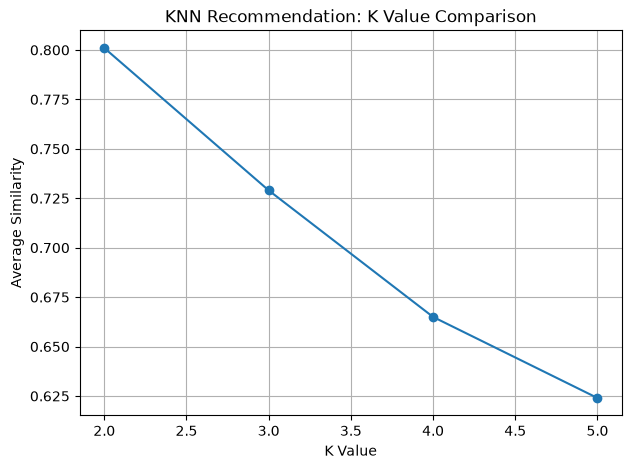

In [10]:
# Visualize K comparison

plt.figure(figsize=(7, 5))

plt.plot(
    k_comparison["K"],
    k_comparison["Average Similarity"],
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Average Similarity")
plt.title("KNN Recommendation: K Value Comparison")
plt.grid(True)

plt.show()

In [11]:
# Save K comparison results

k_comparison.to_csv("k_comparison.csv", index=False)

print("K comparison saved successfully!")

K comparison saved successfully!


In [12]:
# Final recommendations using the best K value

best_k = 2

final_recommendations = recommend_movies("Inception", k=best_k)

print(f"Best K = {best_k}")
print("\nRecommended movies for Inception:")
print(final_recommendations)

Best K = 2

Recommended movies for Inception:
             Movie  Similarity
0     Interstellar       0.816
1  The Dark Knight       0.816


C:\Users\arjun\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [18]:
print("Day 16 - KNN Movie Recommendation")
print("Built a movie recommendation system using K-Nearest Neighbors.")
print("Tested K values: 2, 3, 4, 5")
print("Best K = 2")
print("Average Similarity = 0.801")

Day 16 - KNN Movie Recommendation
Built a movie recommendation system using K-Nearest Neighbors.
Tested K values: 2, 3, 4, 5
Best K = 2
Average Similarity = 0.801
